# 00 · Python for thermodynamics

**Goal:** the Python tools used throughout the course - unit conversions, property tables and how to read
them in code, root finding for inverse problems, and plotting property diagrams - on the substances of the
first notebooks: water and the refrigerant R134a.

Thermodynamics is a subject of tables and diagrams. Doing it in Python means the tables are looked up by a
function instead of by finger, every calculation is reproducible, and a whole diagram costs one loop.

**What you will learn**
- convert units safely and read property tables from files
- interpolate in tables (and why ln p)
- solve inverse problems with a root finder
- draw property diagrams

**Before you start:** basic Python; no thermodynamics needed  ·  **Time:** about 45 min

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from engthermo import datasets, steam, tables
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Units
`engthermo` uses SI units everywhere: K, Pa, J, kg, mol. Textbooks and data sheets use degC, bar, kPa and kJ; convert
at the edges of a calculation, never in the middle:

In [2]:
def C_to_K(t):
    return t + 273.15
bar, kPa, kJ = 1e5, 1e3, 1e3
st = steam.properties(T=C_to_K(350), p=3 * 1e6)
print(f"steam at 350 degC and 3 MPa: h = {st['h']/kJ:.1f} kJ/kg, s = {st['s']/kJ:.4f} kJ/(kg K), v = {st['v']:.5f} m3/kg")

steam at 350 degC and 3 MPa: h = 3116.1 kJ/kg, s = 6.7449 kJ/(kg K), v = 0.09056 m3/kg


## Property tables in a file
The refrigerant tables are plain CSV files. Look at one, then read it with pandas:

In [3]:
path = datasets.path("R134a_saturation.csv")
with open(path, encoding="utf-8") as fh:
    print("".join(fh.readlines()[:5]))
sat = pd.read_csv(path, comment="#")
print(sat.shape)
print(sat.iloc[[0, 20, 40, 60, 70]].to_string(index=False))

# R134a saturation properties from CoolProp (IIR reference state). Columns: T (K), p (Pa), v_f, v_g (m3/kg),
# h_f, h_g (J/kg), s_f, s_g (J/(kg K)).
T_K,p_Pa,v_f,v_g,h_f,h_g,s_f,s_g
233.15,51209,0.000705366,0.361076,148144.1,374003,795.6105,1764.338
235.15,56817.2,0.000708264,0.327553,150658.9,375270.3,806.3338,1761.518

(71, 8)
   T_K      p_Pa      v_f      v_g      h_f      h_g       s_f      s_g
233.15   51209.0 0.000705 0.361076 148144.1 374003.0  795.6105 1764.338
273.15  292803.0 0.000772 0.069309 200000.0 398603.5 1000.0000 1727.086
313.15 1016590.0 0.000872 0.019966 256409.3 419428.5 1190.4770 1711.056
353.15 2633200.0 0.001077 0.006448 322390.3 428813.6 1383.6390 1684.994
373.15 3972380.0 0.001536 0.002681 373297.9 407683.2 1518.7760 1610.925


The header lines say where the numbers come from (CoolProp, with the IIR reference state that refrigeration
handbooks use: h = 200 kJ/kg and s = 1 kJ/(kg K) for saturated liquid at 0 degC). Always read the header:
enthalpies from tables with different reference states cannot be mixed.

## Interpolating in a table
The table lists every 2 K. At -7 degC (266.15 K), a table user interpolates between the rows at 265.15 K and
267.15 K; `np.interp` does the same:

In [4]:
T = 266.15
h_g = np.interp(T, sat.T_K, sat.h_g)
p = np.exp(np.interp(T, sat.T_K, np.log(sat.p_Pa)))                 # pressure: interpolate ln p, which is nearly linear in T
r134 = tables.FluidTable("R134a")
lib = r134.saturated(T=T)
print(f"by hand: h_g = {h_g/1e3:.2f} kJ/kg, p_sat = {p/1e3:.2f} kPa;  library: {lib['vapour']['h']/1e3:.2f} kJ/kg, {lib['p']/1e3:.2f} kPa")

by hand: h_g = 394.47 kJ/kg, p_sat = 225.44 kPa;  library: 394.47 kJ/kg, 225.44 kPa


Interpolating the logarithm of the pressure is the trick to remember: vapour pressure rises exponentially
with temperature, so a straight line through ln p is far more accurate than one through p itself.

## Inverse problems: root finding
Tables give properties from (T, p). Often the question is the other way round - which temperature gives
this enthalpy? A root finder answers it:

In [5]:
p = 1e6
target_h = 3.0e6                                                   # J/kg
f = lambda T: steam.properties(T, p)["h"] - target_h
T_found = optimize.brentq(f, steam.Tsat(p) + 0.01, 1073.15)
print(f"steam at 1 MPa with h = 3000 kJ/kg: T = {T_found - 273.15:.2f} degC   (library: {steam.state_ph(p, target_h)['T'] - 273.15:.2f} degC)")

steam at 1 MPa with h = 3000 kJ/kg: T = 275.97 degC   (library: 275.97 degC)


`brentq` needs a bracket [a, b] on which the function changes sign - here from just above the saturation
temperature to the top of the steam tables. Most of the "inverse" functions of this course (turbine outlets,
flash temperatures, equilibrium conversions) are exactly this pattern.

## Diagrams in one loop

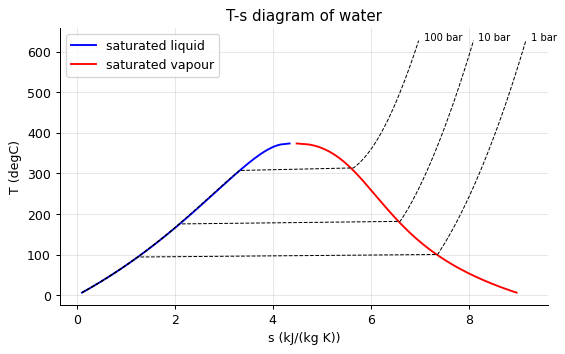

In [6]:
Ts = np.linspace(280, 647, 150)
sats = [steam.saturated(T=T) for T in Ts]
plt.plot([s["liquid"]["s"] / 1e3 for s in sats], Ts - 273.15, "b", label="saturated liquid")
plt.plot([s["vapour"]["s"] / 1e3 for s in sats], Ts - 273.15, "r", label="saturated vapour")
for p in (1e5, 1e6, 1e7):
    T_line = np.linspace(280, 900, 100)
    s_line = [steam.state(T=T, p=p)["s"] / 1e3 if T > steam.Tsat(p) else steam.state(T=T, p=p)["s"] / 1e3 for T in T_line]
    plt.plot(s_line, T_line - 273.15, "k--", lw=0.8)
    plt.text(s_line[-1] + 0.1, T_line[-1] - 273.15, f"{p/1e5:g} bar", fontsize=8)
plt.xlabel("s (kJ/(kg K))"); plt.ylabel("T (degC)"); plt.title("T-s diagram of water"); plt.legend(); plt.show()

## Inside the algorithm: linear interpolation by hand
`np.interp` finds the two table rows around the target and draws a straight line between them:

In [7]:
i = np.searchsorted(sat.T_K.to_numpy(), T)
T_lo, T_hi = sat.T_K[i - 1], sat.T_K[i]
f = (T - T_lo) / (T_hi - T_lo)
print(f"rows {i-1} and {i}: {T_lo:.2f} and {T_hi:.2f} K, fraction {f:.2f} -> h_g = {((1 - f) * sat.h_g[i - 1] + f * sat.h_g[i])/1e3:.2f} kJ/kg")

rows 16 and 17: 265.15 and 267.15 K, fraction 0.50 -> h_g = 394.47 kJ/kg


The saturation dome and three isobars - the diagram every steam-cycle discussion is drawn on (notebook 02).

## Exercises
1. Draw the p-v diagram of water (log axes) with the saturation dome and the isotherms 100, 300, 500 and 700 degC.
2. Interpolate the ammonia saturation table by hand at -12 degC (h_f, h_g, p) and compare with `FluidTable`.
3. **Implement it yourself:** write `Tsat_from_p(p, table)` that inverts the saturation table by interpolating T against ln p, and compare with `FluidTable.Tsat` for R134a at 2, 5 and 10 bar.